## Setup and imports

In [9]:
import matplotlib.pyplot as plt

## Part 1: Data generator

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

def generate_noisy_dataset(funcs, true_f, x_range, n, eps, seed=42):
    """Columns: x, f_1(x), ..., f_d(x), y. y = true_f(x) + uniform noise in [-eps, eps]."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(x_range[0], x_range[1], n)      # sample x uniformly from the range
    data = {"x": x}
    for i, f in enumerate(funcs, start=1):          # extra columns, e.g. x**2, x**3
        data[f"f_{i}(x)"] = f(x)
    data["y"] = true_f(x) + rng.uniform(-eps, eps, n)   # noise is uniform, not Gaussian
    return pd.DataFrame(data)

def split_dataset(df, train_frac=0.8, seed=42):
    """Fixed seed so repeated experiments use the same train/test partition."""
    return train_test_split(df, train_size=train_frac, random_state=seed)

# Quick test: the example from the assignment
df = generate_noisy_dataset([lambda x: x**2, lambda x: x**3], np.log, (0.0, 1.0), 10, 0.1)
train, test = split_dataset(df)
print(df.head(3)); print(len(train), len(test))

          x    f_1(x)    f_2(x)         y
0  0.773956  0.599008  0.463606 -0.282081
1  0.438878  0.192614  0.084534 -0.738180
2  0.858598  0.737190  0.632950 -0.123682
8 2


## Part 2: Linear regression

In [7]:
def build_xy(df):
    """Step 1 of fit: DataFrame -> (X, Y). X has a leading column of 1s for the intercept."""
    Y = df["y"].to_numpy()                          # target vector, shape (n,)
    features = df.drop(columns="y").to_numpy()      # x plus any f_i(x) columns, shape (n, d+1)
    X = np.column_stack([np.ones(len(df)), features])   # prepend the 1s column, shape (n, d+2)
    return X, Y

# Quick test on your Part 1 split
X, Y = build_xy(train)
print(X.shape, Y.shape)   # with the 3-column example: (8, 4) and (8,)
print(X[:2])              # first column should be all 1.0

def compute_beta(X, Y):
    """Step 2 of fit: normal equation, beta = (X^T X)^{-1} X^T Y."""
    XtX = X.T @ X                  # shape (d+2, d+2), small square matrix
    XtY = X.T @ Y                  # shape (d+2,)
    beta = np.linalg.inv(XtX) @ XtY
    return beta                    # beta[0] is the intercept, then one weight per input column

# Quick test: should return one weight per column of X
beta = compute_beta(X, Y)
print(beta.shape, beta)

def fit(train_df):
    X, Y = build_xy(train_df)      # step 1
    return compute_beta(X, Y)      # steps 2 and 3: compute and output the weight vector

def predict(beta, df):
    """Predictions y_hat = X @ beta, one per row. Accepts a DataFrame with or without 'y'."""
    features = df.drop(columns="y", errors="ignore").to_numpy()   # ignore 'y' if present
    X = np.column_stack([np.ones(len(df)), features])             # same 1s column as in training
    return X @ beta                                               # shape (n,)

# Quick test on the test split
beta = fit(train)
preds = predict(beta, test)
print(preds.shape, preds)    # one prediction per test row

def evaluate_model(preds, y_true):
    """RMSE: mean of squared errors, then square root."""
    errors = preds - y_true                 # error for each prediction
    return np.sqrt(np.mean(errors ** 2))    # mean of squares, then sqrt

# Quick test on the test split
print(evaluate_model(predict(beta, test), test["y"].to_numpy()))


(8, 4) (8,)
[[1.         0.97562235 0.95183897 0.92863538]
 [1.         0.77395605 0.59900797 0.46360584]]
(4,) [-3.09986279  8.52500332 -9.03510751  3.56685683]
(2,) [-2.14848761 -0.79719181]
0.12004056804737323


## Part 3: Regression tree

In [13]:
from dataclasses import dataclass
from typing import Optional

@dataclass
class Node:
    """One tree node. A leaf has `prediction`; an internal node has a split and two children."""
    prediction: Optional[float] = None    # leaf only: mean y of the training records here
    feature: Optional[int] = None         # internal only: column index used for the split
    threshold: Optional[float] = None     # internal only: go left if x[feature] < threshold
    left: Optional["Node"] = None
    right: Optional["Node"] = None
    n_records: int = 0                    # records that reached this node (needed for Q10)

    def is_leaf(self):
        return self.left is None and self.right is None

# Quick test: a tiny tree with one split and two leaves
tree = Node(feature=0, threshold=2.5,
            left=Node(prediction=0.0, n_records=2), right=Node(prediction=5.0, n_records=2), n_records=4)
print(tree.is_leaf(), tree.left.is_leaf(), tree.right.prediction)   # False True 5.0

False True 5.0


In [14]:
def best_split(X, y):
    """Best (feature, threshold) for a node. X: (n, d) features, y: (n,) targets.
    Returns (feature_index, threshold, total_sse), or None if no valid split exists."""
    n, d = X.shape
    best = None
    for j in range(d):
        order = np.argsort(X[:, j], kind="stable")
        xs, ys = X[order, j], y[order]
        # prefix sums give each group's SSE in O(1): SSE = sum(y^2) - (sum y)^2 / count
        cs, cs2 = np.cumsum(ys), np.cumsum(ys ** 2)
        total_s, total_s2 = cs[-1], cs2[-1]
        k = np.arange(1, n)                       # left group = first k sorted records
        valid = xs[1:] > xs[:-1]                  # only split between distinct x values
        if not valid.any():
            continue
        left_sse = cs2[:-1] - cs[:-1] ** 2 / k
        right_n = n - k
        right_sse = (total_s2 - cs2[:-1]) - (total_s - cs[:-1]) ** 2 / right_n
        total = np.where(valid, left_sse + right_sse, np.inf)
        i = int(np.argmin(total))
        if total[i] < np.inf and (best is None or total[i] < best[2]):
            best = (j, (xs[i] + xs[i + 1]) / 2, float(total[i]))   # midpoint threshold
    return best

# Quick test: a clear step in y should split between x=2 and x=3
X_t = np.array([[1.], [2.], [3.], [4.]]); y_t = np.array([0., 0., 5., 5.])
print(best_split(X_t, y_t))    # expect feature 0, threshold 2.5, error 0.0

class RegressionTree:
    def __init__(self):
        self.root = None

    def fit(self, dataset, min_records):
        """dataset: DataFrame with y as the last column; the other columns are features."""
        X = dataset.drop(columns="y").to_numpy()      # features only, no column of 1s
        y = dataset["y"].to_numpy()
        self.root = self._build(X, y, min_records)
        return self

    def _build(self, X, y, min_records):
        n = len(y)
        if n < min_records:                           # too small to split: leaf
            return Node(prediction=float(y.mean()), n_records=n)
        split = best_split(X, y)
        if split is None:                             # no valid split (identical x values): leaf
            return Node(prediction=float(y.mean()), n_records=n)
        feature, threshold, _ = split
        go_left = X[:, feature] < threshold           # same rule as best_split
        return Node(feature=feature, threshold=threshold, n_records=n,
                    left=self._build(X[go_left], y[go_left], min_records),
                    right=self._build(X[~go_left], y[~go_left], min_records))

# Quick test: build trees on the cubic, noise 0.1, (x,y) training data
df = generate_noisy_dataset([], TRUE_FUNCS["Cubic"], (0.0, 1.0), 1000, 0.1)
train, test = split_dataset(df)

def tree_stats(node):
    """Returns (number of nodes, number of leaves, list of leaf sizes)."""
    if node.is_leaf():
        return 1, 1, [node.n_records]
    l, r = tree_stats(node.left), tree_stats(node.right)
    return 1 + l[0] + r[0], l[1] + r[1], l[2] + r[2]

for m in [1000, 50, 1]:
    nodes, leaves, sizes = tree_stats(RegressionTree().fit(train, m).root)
    print(f"min_records={m}: {nodes} nodes, {leaves} leaves, leaf sizes {min(sizes)}-{max(sizes)}")

(0, np.float64(2.5), 0.0)
min_records=1000: 1 nodes, 1 leaves, leaf sizes 800-800
min_records=50: 65 nodes, 33 leaves, leaf sizes 2-49
min_records=1: 1599 nodes, 800 leaves, leaf sizes 1-1


## Experiments (linear regression)

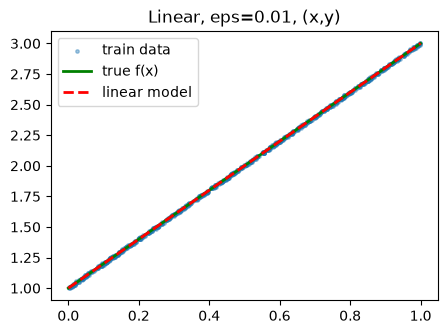

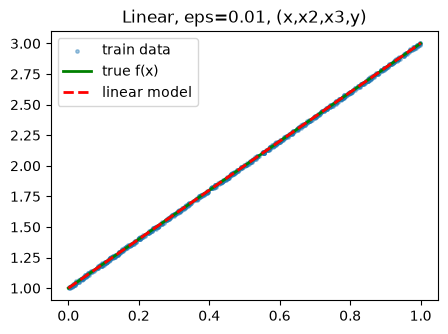

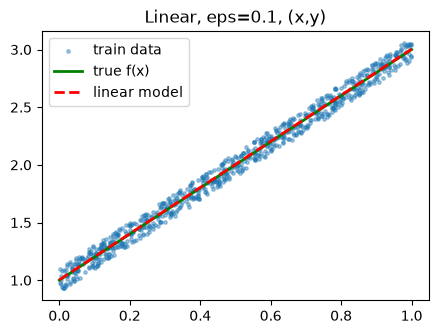

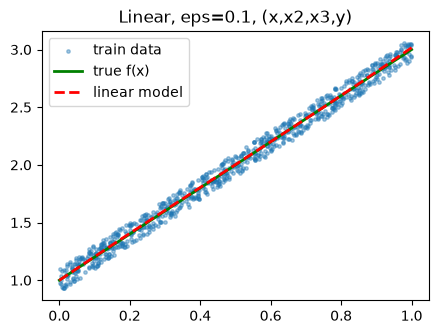

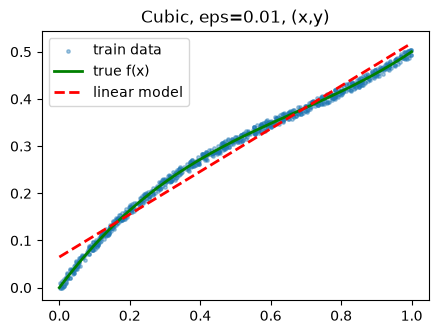

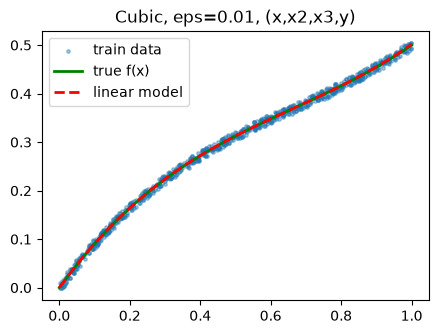

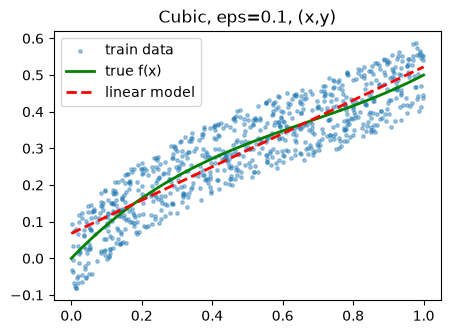

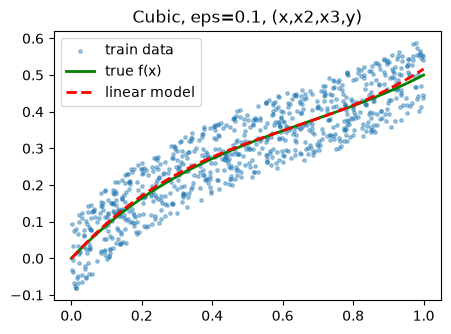

,true_f,noise,schema,train_rmse,test_rmse,error_at_x=10
0,Linear,0.01,"(x,y)",0.0059,0.0054,0.0013
1,Linear,0.01,"(x,x2,x3,y)",0.0059,0.0054,14.0181
2,Linear,0.10,"(x,y)",0.0588,0.0542,0.0126
3,Linear,0.10,"(x,x2,x3,y)",0.0587,0.0543,140.1815
4,Cubic,0.01,"(x,y)",0.0217,0.0215,-405.4019
5,Cubic,0.01,"(x,x2,x3,y)",0.0059,0.0054,14.0181
6,Cubic,0.10,"(x,y)",0.0623,0.0594,-405.3906
7,Cubic,0.10,"(x,x2,x3,y)",0.0587,0.0543,140.1815


In [10]:
TRUE_FUNCS = {"Linear": lambda x: 2*x + 1, "Cubic": lambda x: 0.5*x**3 - x**2 + x}
SCHEMAS = {"(x,y)": [], "(x,x2,x3,y)": [lambda x: x**2, lambda x: x**3]}

def x_to_frame(x, funcs):
    """Build a DataFrame of x plus the extra columns, for plotting the full model curve."""
    d = {"x": x}
    for i, f in enumerate(funcs, start=1):
        d[f"f_{i}(x)"] = f(x)
    return pd.DataFrame(d)

def run_lr(func_name, eps, schema_name, n=1000, plot=True):
    true_f, extra = TRUE_FUNCS[func_name], SCHEMAS[schema_name]
    df = generate_noisy_dataset(extra, true_f, (0.0, 1.0), n, eps)
    train, test = split_dataset(df)
    beta = fit(train)
    train_rmse = evaluate_model(predict(beta, train), train["y"].to_numpy())
    test_rmse = evaluate_model(predict(beta, test), test["y"].to_numpy())
    err10 = predict(beta, x_to_frame(np.array([10.0]), extra))[0] - true_f(10.0)   # Q5
    if plot:
        grid = np.linspace(0, 1, 200)
        plt.figure(figsize=(5, 3.5))
        plt.scatter(train["x"], train["y"], s=6, alpha=0.4, label="train data")
        plt.plot(grid, true_f(grid), "g-", lw=2, label="true f(x)")
        plt.plot(grid, predict(beta, x_to_frame(grid, extra)), "r--", lw=2, label="linear model")
        plt.title(f"{func_name}, eps={eps}, {schema_name}"); plt.legend(); plt.show()
    return {"true_f": func_name, "noise": eps, "schema": schema_name,
            "train_rmse": train_rmse, "test_rmse": test_rmse, "error_at_x=10": err10}

# Q3 (schema (x,y)) and Q4 (schema (x,x2,x3,y)): 8 runs, 8 plots, one summary table
rows = [run_lr(f, e, s) for f in TRUE_FUNCS for e in (0.01, 0.1) for s in SCHEMAS]
pd.DataFrame(rows).round(4)

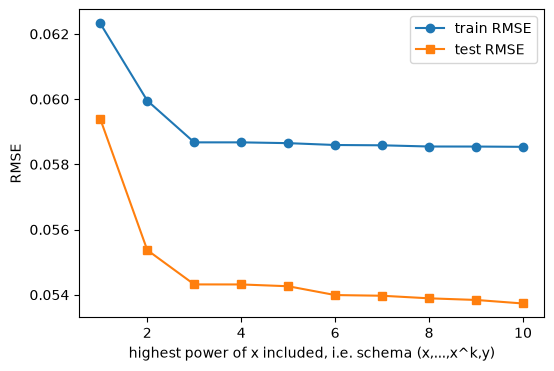

,max_power,train_rmse,test_rmse
0,1,0.06232,0.05939
1,2,0.05995,0.05537
2,3,0.05867,0.05432
3,4,0.05867,0.05432
4,5,0.05865,0.05426
5,6,0.05859,0.05399
6,7,0.05858,0.05397
7,8,0.05855,0.05389
8,9,0.05855,0.05384
9,10,0.05854,0.05373


In [11]:
def run_degree_sweep(max_deg=10, eps=0.1, n=1000):
    """Cubic true function; schemas (x), (x,x2), ..., (x,x2,...,x10)."""
    true_f = TRUE_FUNCS["Cubic"]
    out = []
    for deg in range(1, max_deg + 1):
        # k=k freezes the power for each lambda (otherwise they all use the last k)
        extra = [lambda x, k=k: x**k for k in range(2, deg + 1)]
        df = generate_noisy_dataset(extra, true_f, (0.0, 1.0), n, eps)
        train, test = split_dataset(df)
        beta = fit(train)
        out.append({"max_power": deg,
                    "train_rmse": evaluate_model(predict(beta, train), train["y"].to_numpy()),
                    "test_rmse": evaluate_model(predict(beta, test), test["y"].to_numpy())})
    return pd.DataFrame(out)

res = run_degree_sweep()
plt.figure(figsize=(6, 4))
plt.plot(res["max_power"], res["train_rmse"], "o-", label="train RMSE")
plt.plot(res["max_power"], res["test_rmse"], "s-", label="test RMSE")
plt.xlabel("highest power of x included, i.e. schema (x,...,x^k,y)")
plt.ylabel("RMSE"); plt.legend(); plt.show()
res.round(5)

## Experiments (tree)